# Матрьонін Олександр Євгенович
<span style="color: blue;">Група: ІПЗ-23007б</span>

**Варіант: 9**

In [ ]:
import os
import sys

print("ОС:", os.name)
print("Шлях до папки проекту:", os.getcwd())
print("Назва віртуального оточення:", os.path.basename(sys.prefix))

ОС: posix
Шлях до папки проекту: /home/jovyan
Назва віртуального оточення: conda


## 1. Створити програму для генерації довільного масиву із 44 цілих чисел, які не перевищують по модулю 99, з наступними властивостями:
- ### При кожному запуску програми масив повинен бути різним.
- ### Масив повинен містити від 3 до 4 максимальних (однакових) елементів.
- ### Масив повинен містити 30 відсотків додатних елементів (розташованих в довільних місцях)

In [2]:
import random
import numpy as np

n = 44
max_abs = 99
total_positive = round(n * 0.3)
count_max = random.randint(3, 4)
max_val = random.randint(2, max_abs)

remaining_positive_count = total_positive - count_max
remaining_negative_count = n - total_positive

arr = [max_val] * count_max
arr += [random.randint(1, max_val - 1) for _ in range(remaining_positive_count)]
arr += [random.randint(-max_abs, -1) for _ in range(remaining_negative_count)]

random.shuffle(arr)
arr = np.array(arr)
print(arr)

[  9 -15  10 -60 -60   9 -46 -62 -91   7 -22  -5   5 -34 -64 -23  10 -12
   2 -41 -35 -78 -33 -47 -59 -90 -53  10 -49   4 -67 -77 -10 -32  10   5
 -62 -42   4 -49   1 -80 -21 -58]


## 2. Зберегти згенерований масив в файл.

In [3]:
with open('array.txt', 'w') as f:
    f.write(' '.join(map(str, arr)))
print("Масив збережено у файл array.txt")

Масив збережено у файл array.txt


## 3. Створити програму, яка зчитує із файлу згенерований масив попередньою програмою і виводить його на екран.

In [4]:
with open('array.txt', 'r') as f:
    arr = np.array(list(map(int, f.read().split())))
print(arr)

[  9 -15  10 -60 -60   9 -46 -62 -91   7 -22  -5   5 -34 -64 -23  10 -12
   2 -41 -35 -78 -33 -47 -59 -90 -53  10 -49   4 -67 -77 -10 -32  10   5
 -62 -42   4 -49   1 -80 -21 -58]


## 4. Візуалізувати масив за допомогою стовпчастої горизонтальної діаграми. Виділити кольором максимальні елементи, а також вказати ці значення на діаграмі. Виділити іншим кольором додатні елементи.

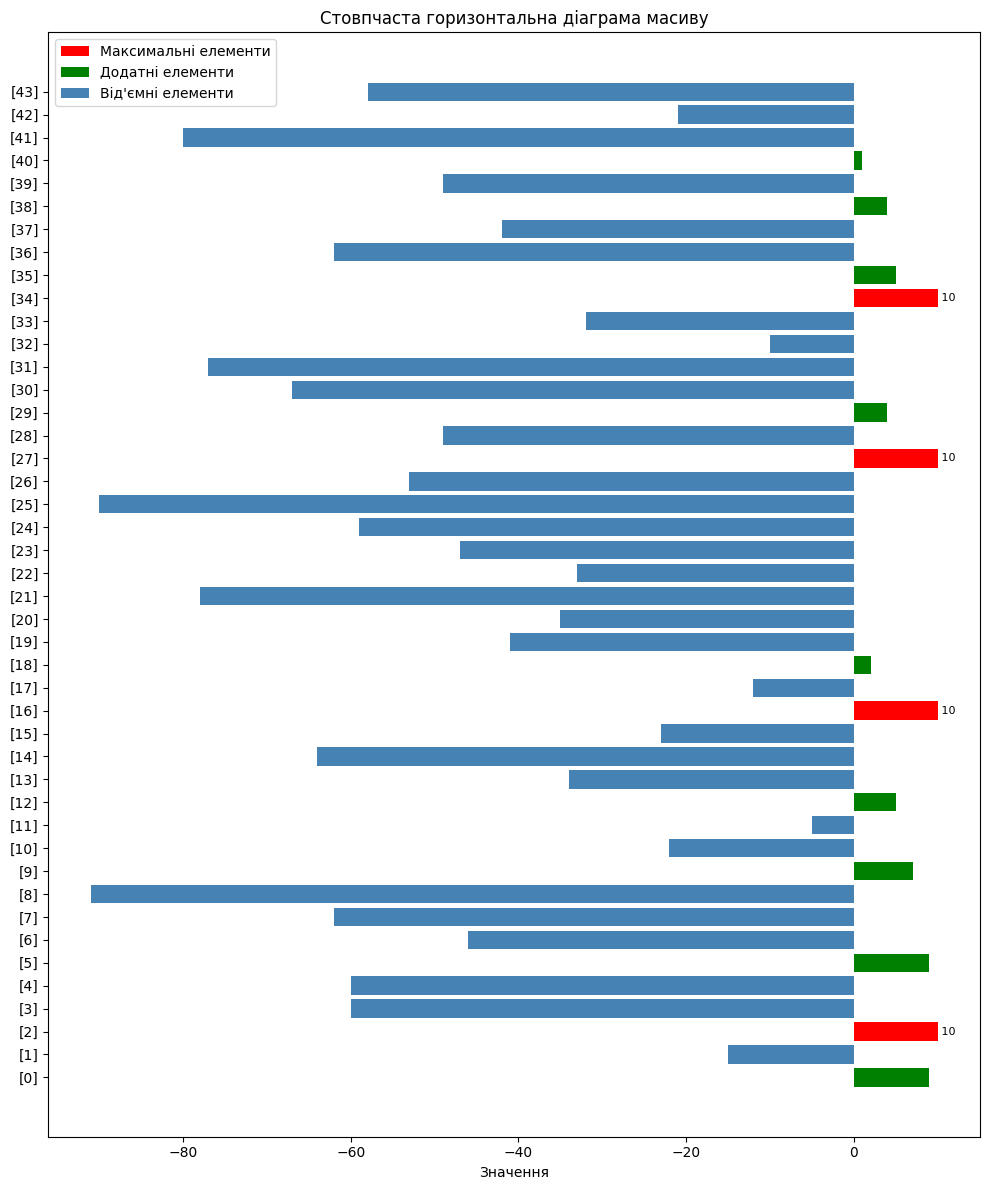

In [5]:
import matplotlib.pyplot as plt

max_val = arr.max()
colors = []
for x in arr:
    if x == max_val:
        colors.append('red')
    elif x > 0:
        colors.append('green')
    else:
        colors.append('steelblue')

fig, ax = plt.subplots(figsize=(10, 12))
y_pos = range(len(arr))
ax.barh(y_pos, arr, color=colors)

for i, val in enumerate(arr):
    if val == max_val:
        ax.text(val, i, f' {val}', va='center', fontsize=8)

ax.set_yticks(y_pos)
ax.set_yticklabels([f'[{i}]' for i in range(len(arr))])
ax.set_title('Стовпчаста горизонтальна діаграма масиву')
ax.set_xlabel('Значення')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='Максимальні елементи'),
    Patch(facecolor='green', label='Додатні елементи'),
    Patch(facecolor='steelblue', label='Від\'ємні елементи')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

## 5. Порахувати номери позицій другого та третього максимальних елементів.

In [6]:
max_val = arr.max()
max_positions = [i for i, x in enumerate(arr) if x == max_val]
print(f"Максимальне значення: {max_val}")
print(f"Позиція другого максимального елемента: {max_positions[1]}")
print(f"Позиція третього максимального елемента: {max_positions[2]}")

Максимальне значення: 10
Позиція другого максимального елемента: 16
Позиція третього максимального елемента: 27


## 6. Порахувати кількість та суму елементів масиву, розташованих між другим та третім додатними елементами.

In [7]:
positive_positions = [i for i, x in enumerate(arr) if x > 0]
pos2 = positive_positions[1]
pos3 = positive_positions[2]
between = arr[pos2 + 1:pos3]
print(f"Позиція другого додатного елемента: {pos2}")
print(f"Позиція третього додатного елемента: {pos3}")
print(f"Елементи між ними: {between}")
print(f"Кількість елементів: {len(between)}")
print(f"Сума елементів: {sum(between)}")

Позиція другого додатного елемента: 2
Позиція третього додатного елемента: 5
Елементи між ними: [-60 -60]
Кількість елементів: 2
Сума елементів: -120


## 7. Перетворити масив таким чином, щоб спочатку йшли всі додатні елементи, відсортовані за зростанням, потім всі інші елементи, відсортовані за збиванням. Вивести отриманий масив та його графічну діаграму на екран.

[  1   2   4   4   5   5   7   9   9  10  10  10  10  -5 -10 -12 -15 -21
 -22 -23 -32 -33 -34 -35 -41 -42 -46 -47 -49 -49 -53 -58 -59 -60 -60 -62
 -62 -64 -67 -77 -78 -80 -90 -91]


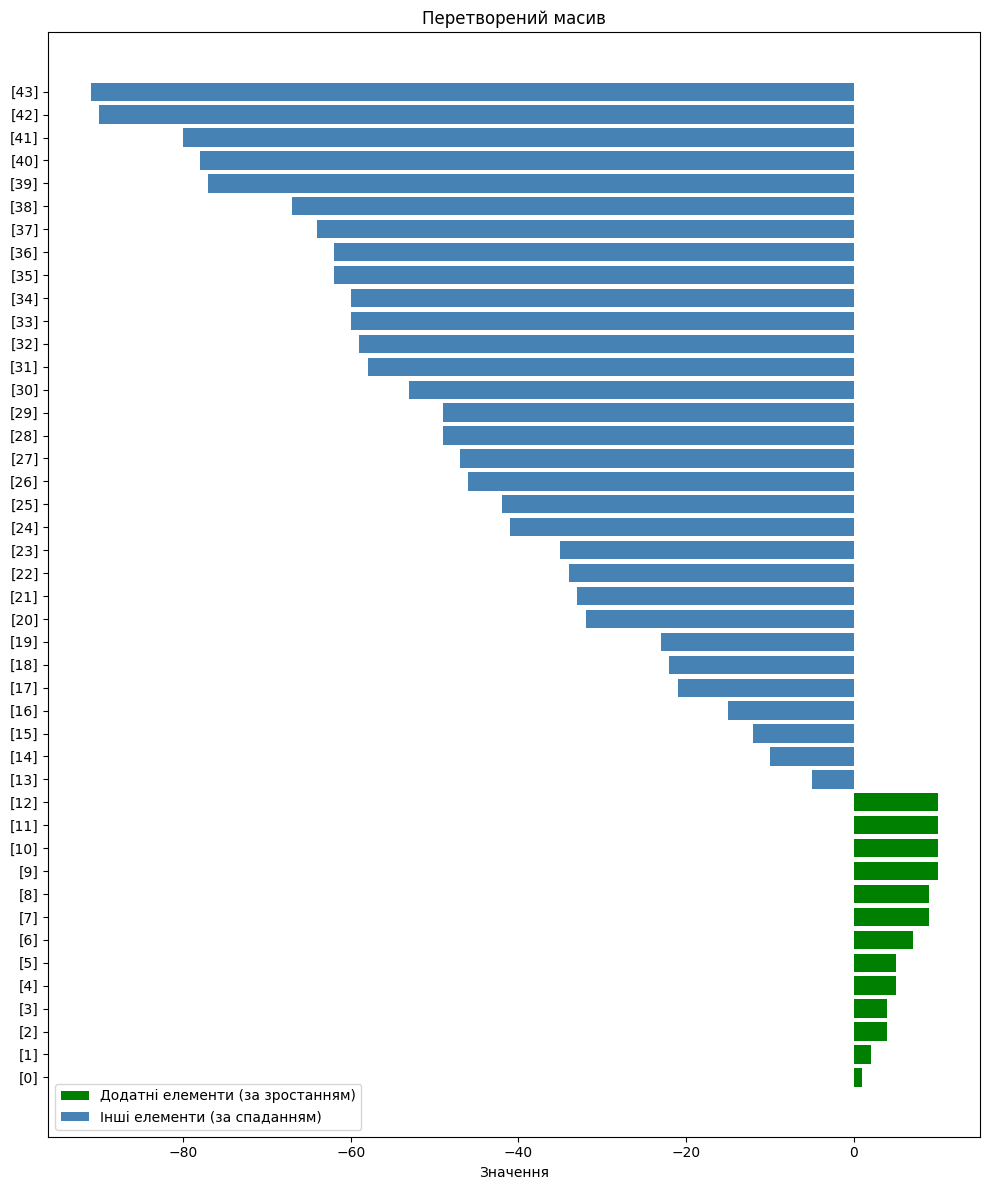

In [8]:
positive = np.array(sorted([x for x in arr if x > 0]))
others = np.array(sorted([x for x in arr if x <= 0], reverse=True))
new_arr = np.concatenate([positive, others])
print(new_arr)

colors2 = ['green' if x > 0 else 'steelblue' for x in new_arr]
fig, ax = plt.subplots(figsize=(10, 12))
y_pos = range(len(new_arr))
ax.barh(y_pos, new_arr, color=colors2)
ax.set_yticks(y_pos)
ax.set_yticklabels([f'[{i}]' for i in range(len(new_arr))])
ax.set_title('Перетворений масив')
ax.set_xlabel('Значення')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='Додатні елементи (за зростанням)'),
    Patch(facecolor='steelblue', label='Інші елементи (за спаданням)')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()